In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset")

print("Path to dataset files:", path)

KeyboardInterrupt: 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('student-lifestyle-and-stress-dataset.csv')

In [4]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [5]:
df.shape

(25500, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  str    
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 1.8 MB


In [7]:
min=df.isna().mean()*100
print(min[min>0].sort_values(ascending=False))

Sleep_Hours           5.227451
Month                 5.152941
Social_Media_Hours    5.145098
Attendance            5.117647
Family_Support        5.062745
Study_Hours           5.007843
Exam_Pressure         4.980392
Student_Type          4.909804
dtype: float64


In [8]:
num_cols = [
    'Sleep_Hours',
    'Social_Media_Hours',
    'Attendance',
    'Study_Hours',
    'Exam_Pressure'
]

for col in num_cols:
    print(col)
    print("Skewness:", df[col].skew())
    print("-"*30)

Sleep_Hours
Skewness: -0.23200645724216598
------------------------------
Social_Media_Hours
Skewness: 0.25356734284263316
------------------------------
Attendance
Skewness: -1.1267077935524452
------------------------------
Study_Hours
Skewness: 0.5548433521388645
------------------------------
Exam_Pressure
Skewness: 0.005089404029236175
------------------------------


In [9]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

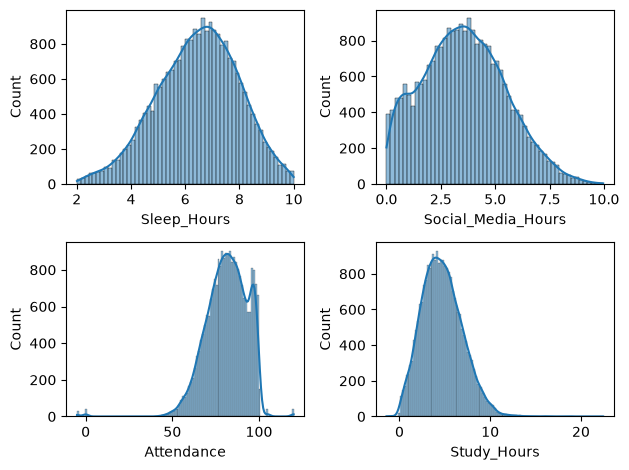

In [10]:
plotting('Sleep_Hours',1)
plotting('Social_Media_Hours',2)
plotting('Attendance',3)
plotting('Study_Hours',4)
plt.tight_layout()


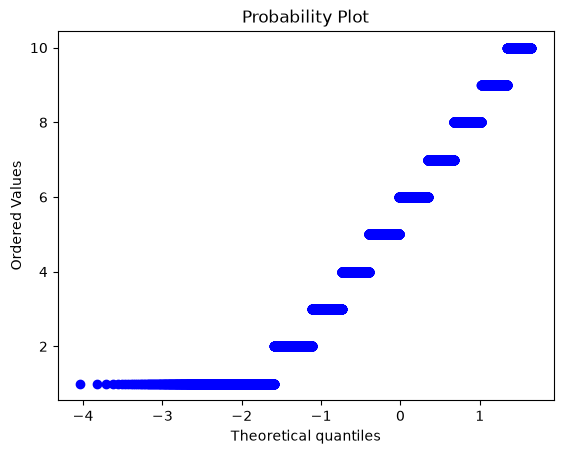

In [11]:
from scipy.stats import probplot

probplot(df['Exam_Pressure'], plot=plt)
plt.show()

<Axes: xlabel='Student_Type', ylabel='count'>

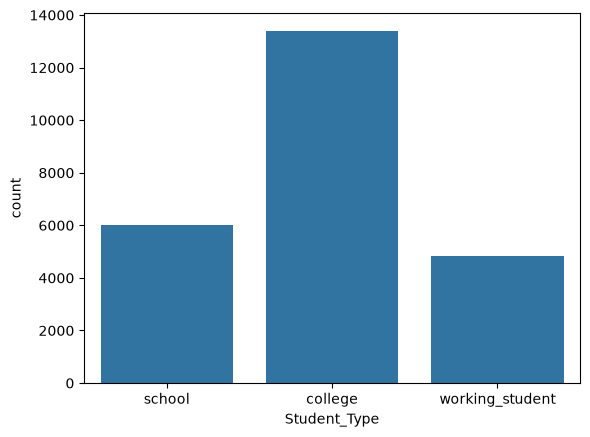

In [12]:
sns.countplot(x='Student_Type', data=df)

<Axes: xlabel='Family_Support', ylabel='count'>

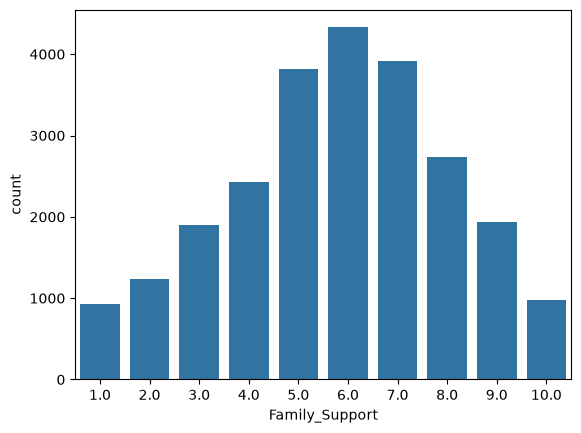

In [13]:
sns.countplot(x='Family_Support', data=df)

<Axes: xlabel='Month', ylabel='count'>

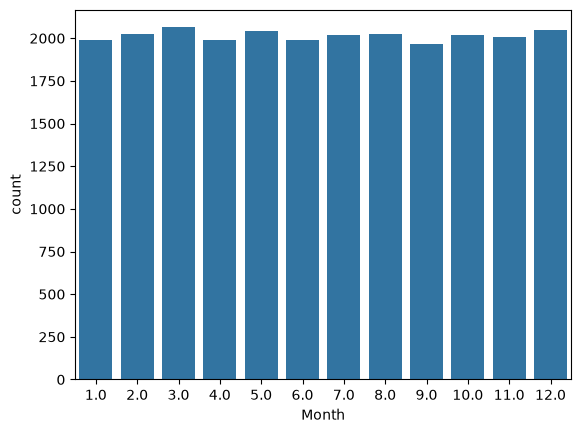

In [14]:
sns.countplot(x='Month', data=df)

In [15]:
df['Student_Type']=df['Student_Type'].fillna(df['Student_Type'].mode()[0])

In [22]:
df.tail()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
25495,college,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0
25496,school,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1
25497,college,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1
25498,school,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0
25499,college,7.419726,6.442748,3.356066,81.452460,9.0,5.0,6.0,1


In [16]:
df['Attendance']=df['Attendance'].fillna(df['Attendance'].median())
df['Study_Hours']=df['Study_Hours'].fillna(df['Study_Hours'].median())    
df['Exam_Pressure'] = df['Exam_Pressure'].fillna(
    df['Exam_Pressure'].median()
)
df['Sleep_Hours']=df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean())
df['Social_Media_Hours']=df['Social_Media_Hours'].fillna(df['Social_Media_Hours'].median())
df.isna().sum()

Student_Type             0
Sleep_Hours              0
Study_Hours              0
Social_Media_Hours       0
Attendance               0
Exam_Pressure            0
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [23]:
df['Attendance'].describe()

count    24195.000000
mean        81.270961
std         12.052045
min         -5.000000
25%         73.738894
50%         81.942959
75%         90.106859
max        120.000000
Name: Attendance, dtype: float64

In [24]:
df[df['Attendance'] > 100]

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
160,school,NaN,5.974761,0.461316,105.0,1.0,3.0,3.0,0
330,school,6.649074,2.419229,3.781422,120.0,8.0,2.0,NaN,0
422,working_student,6.255770,5.304709,2.337707,105.0,NaN,NaN,9.0,0
473,college,3.573272,8.869251,NaN,105.0,4.0,9.0,10.0,1
487,college,4.429828,5.079684,6.168412,105.0,7.0,5.0,9.0,1
...,...,...,...,...,...,...,...,...,...
24826,college,4.526881,8.351260,2.570856,105.0,3.0,8.0,6.0,0
24911,working_student,5.674409,6.955939,5.268237,105.0,8.0,6.0,1.0,1
24941,school,7.466734,3.871580,7.768004,105.0,4.0,2.0,12.0,0
24946,working_student,2.260330,5.127902,5.171093,120.0,NaN,7.0,1.0,1


In [17]:
df['Family_Support'] = df['Family_Support'].fillna(
    df['Family_Support'].median()
)

In [18]:
df['Month'] = df['Month'].fillna(
    df['Month'].median()
)

In [19]:
df.isna().sum()

Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64

## Handling Duplicate Values


In [24]:
df['Attendance'].unique()

array([81.94295863, 93.97846478, 64.42125337, ..., 79.81893027,
       96.68077345, 81.4524603 ], shape=(23576,))

In [21]:
dup=df.duplicated().sum()
dup

np.int64(24)

In [22]:
df=df.drop_duplicates()

In [26]:
df[df['Attendance'] > 100]['Attendance'].value_counts().sort_index()

Attendance
105.0    42
120.0    40
Name: count, dtype: int64

In [28]:
df['Stress_Level'].value_counts()

Stress_Level
0    17837
1     7639
Name: count, dtype: int64

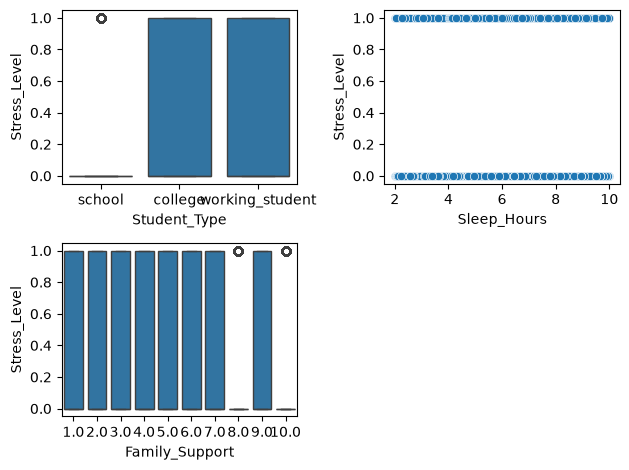

In [32]:
plt.subplot(2,2,1)
sns.boxplot(x='Student_Type', y='Stress_Level', data=df)

plt.subplot(2,2,2)
sns.scatterplot(x='Sleep_Hours', y='Stress_Level', data=df)

plt.subplot(2,2,3)
sns.boxplot(x='Family_Support', y='Stress_Level', data=df)
plt.tight_layout()

In [34]:
df.groupby('Student_Type')['Stress_Level'].mean()
df.groupby('Family_Support')['Stress_Level'].mean()
df.groupby('Exam_Pressure')['Stress_Level'].mean()
df.groupby('Sleep_Hours')['Stress_Level'].mean()
df.groupby('Study_Hours')['Stress_Level'].mean()

Study_Hours
-1.433434     0.0
-1.256501     0.0
-1.224952     0.0
-1.188134     0.0
-1.034671     0.0
             ... 
 18.792279    0.0
 19.738097    1.0
 21.762168    1.0
 21.979263    1.0
 22.444460    1.0
Name: Stress_Level, Length: 24223, dtype: float64